#  Exploratory Data Analysis: Fake News Detection

---

**Dataset:** LIAR Dataset (LIAR: A Benchmark Dataset for Fake News Detection)  

---

## 📋 Table of Contents

1. [Introduction & Objectives](#1)
2. [Imports & Setup](#2)
3. [Data Loading & Preprocessing](#3)
4. [Dataset Overview](#4)
5. [Missing Value Analysis](#5)
6. [Target Variable Analysis](#6)
7. [Text-Based Feature Analysis](#7)
   - 7.1 Statement Length & Word Count
   - 7.2 Lexical Diversity
   - 7.3 Readability Metrics
   - 7.4 Sensationalism Indicators
8. [Speaker & Metadata Analysis](#8)
9. [Political Affiliation Analysis](#9)
10. [Correlation Analysis](#10)
11. [Historical Credibility Scores](#11)

<a id='1'></a>
## 1. Introduction & Objectives

### Background

The proliferation of misinformation across digital media platforms presents a critical societal challenge. Automated fake news detection using Natural Language Processing (NLP) and Machine Learning (ML) offers a scalable solution to assist fact-checkers and reduce misinformation spread.

This EDA is conducted on the **LIAR dataset**, a benchmark collection of ~12,800 political statements sourced from PolitiFact.com, each labelled across six veracity levels by expert fact-checkers. For this project, the task is framed as a **binary classification problem**:
- **Real (0):** `true`, `mostly-true`
- **Fake (1):** `false`, `barely-true`, `pants-fire`

### Objectives

| # | Objective |
|---|---|
| 1 | Understand the structure, shape, and quality of the dataset |
| 2 | Analyse the distribution of the target variable (class balance) |
| 3 | Extract and examine linguistic features from statement text |
| 4 | Investigate metadata signals (speaker, party, job, context) |
| 5 | Identify discriminative features to inform downstream ML modelling |



<a id='2'></a>
## 2. Imports & Setup

In [24]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# ── NLP / Text ──────────────────────────────────────────────────────────────
import textstat
from wordcloud import WordCloud

# ── Plot Aesthetics ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = {0: '#2196F3', 1: '#F44336'}   # Blue = Real, Red = Fake
LABEL_MAP = {0: 'Real', 1: 'Fake'}

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("✅ All libraries imported successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   seaborn : {sns.__version__}")

✅ All libraries imported successfully.
   pandas  : 2.3.3
   numpy   : 2.4.1
   seaborn : 0.13.2


<a id='3'></a>
## 3. Data Loading & Preprocessing

In [25]:
# ── Column Schema ────────────────────────────────────────────────────────────
COLUMNS = [
    'id', 'label', 'statement', 'subject',
    'speaker', 'speaker_job', 'state_info', 'party_affiliation',
    'barely_true_counts', 'false_counts', 'half_true_counts',
    'mostly_true_counts', 'pants_on_fire_counts', 'context'
]

# ── Load Data ─────────────────────────────────────────────────────────────────
# Update the path below to your local dataset location
DATA_PATH = r"C:\Users\kiran\OneDrive\Desktop\predicitve-3\dataset\train.tsv"

raw_df = pd.read_csv(DATA_PATH, sep='\t', header=None, names=COLUMNS)

print(f"Raw dataset loaded: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
print(f"\nOriginal label distribution:")
print(raw_df['label'].value_counts().to_string())

Raw dataset loaded: 10,240 rows × 14 columns

Original label distribution:
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839


In [26]:
# ── Label Binarisation ────────────────────────────────────────────────────────
# Exclude ambiguous 'half-true' samples
df = raw_df[raw_df['label'] != 'half-true'].copy()

LABEL_MAPPING = {
    'true': 0,
    'mostly-true': 0,
    'false': 1,
    'barely-true': 1,
    'pants-fire': 1
}
df['label'] = df['label'].map(LABEL_MAPPING)

# ── Fill Missing Categoricals ─────────────────────────────────────────────────
CAT_COLS = ['subject', 'speaker', 'speaker_job', 'state_info', 'party_affiliation', 'context']
df[CAT_COLS] = df[CAT_COLS].fillna('Unknown')

print(f"After filtering — Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Rows removed (half-true): {len(raw_df) - len(df):,}")
print(f"\nBinary label counts:")
print(df['label'].value_counts().rename(LABEL_MAP).to_string())

After filtering — Dataset shape: 8,126 rows × 14 columns
Rows removed (half-true): 2,114

Binary label counts:
label
Fake    4488
Real    3638


<a id='4'></a>
## 4. Dataset Overview

In [27]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\n{'Shape':<25}: {df.shape}")
print(f"{'Total Samples':<25}: {len(df):,}")
print(f"{'Real Samples (label=0)':<25}: {(df['label']==0).sum():,}")
print(f"{'Fake Samples (label=1)':<25}: {(df['label']==1).sum():,}")
print(f"{'Duplicate Rows':<25}: {df.duplicated().sum():,}")
print("\n")
df.head()

DATASET OVERVIEW

Shape                    : (8126, 14)
Total Samples            : 8,126
Real Samples (label=0)   : 3,638
Fake Samples (label=1)   : 4,488
Duplicate Rows           : 0




,id,label,statement,subject,speaker,speaker_job,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635.json,1,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
2,324.json,0,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,1,Health care reform legislation is likely to ma...,health-care,blog-posting,Unknown,Unknown,none,7.0,19.0,3.0,5.0,44.0,a news release
5,12465.json,0,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece
6,2342.json,1,Jim Dunnam has not lived in the district he re...,candidates-biography,republican-party-texas,Unknown,Texas,republican,3.0,1.0,1.0,3.0,1.0,a press release.


In [28]:
# Data types and memory
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 8126 entries, 0 to 10239
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8126 non-null   object 
 1   label                 8126 non-null   int64  
 2   statement             8126 non-null   object 
 3   subject               8126 non-null   object 
 4   speaker               8126 non-null   object 
 5   speaker_job           8126 non-null   object 
 6   state_info            8126 non-null   object 
 7   party_affiliation     8126 non-null   object 
 8   barely_true_counts    8124 non-null   float64
 9   false_counts          8124 non-null   float64
 10  half_true_counts      8124 non-null   float64
 11  mostly_true_counts    8124 non-null   float64
 12  pants_on_fire_counts  8124 non-null   float64
 13  context               8126 non-null   object 
dtypes: float64(5), int64(1), object(8)
memory usage: 5.1 MB


In [29]:
# Statistical summary of numeric columns
numeric_cols = ['barely_true_counts', 'false_counts', 'half_true_counts',
                'mostly_true_counts', 'pants_on_fire_counts']
df[numeric_cols].describe().round(2)

,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts
count,8124.00,8124.00,8124.00,8124.00,8124.00
mean,11.45,13.47,16.49,15.97,6.64
std,18.83,24.39,35.07,35.28,17.14
min,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00
50%,2.00,2.00,3.00,3.00,1.00
75%,12.00,15.00,12.00,11.00,6.00
max,70.00,114.00,160.00,163.00,105.00


<a id='5'></a>
## 5. Missing Value Analysis

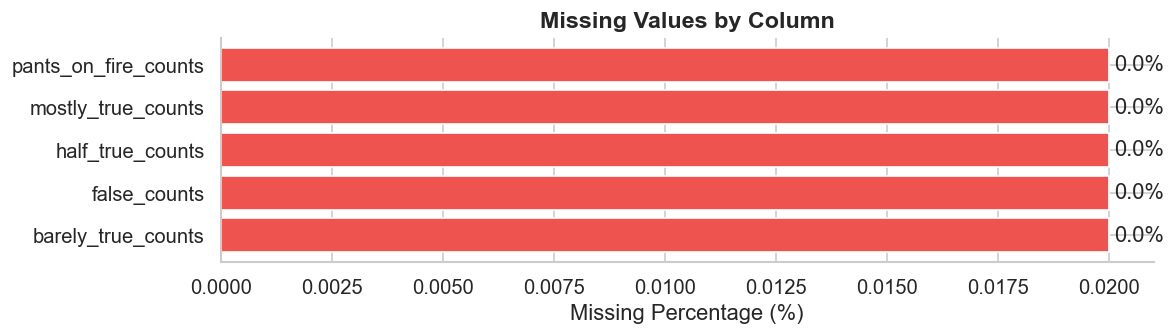

                      Missing Count  Missing %
barely_true_counts                2       0.02
false_counts                      2       0.02
half_true_counts                  2       0.02
mostly_true_counts                2       0.02
pants_on_fire_counts              2       0.02


In [30]:
# Compute missing stats
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

if missing.empty:
    print("✅ No missing values after imputation.")
else:
    fig, ax = plt.subplots(figsize=(10, max(3, len(missing) * 0.5)))
    bars = ax.barh(missing.index, missing['Missing %'], color='#EF5350')
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(missing)

<a id='6'></a>
## 6. Target Variable Analysis

Class balance is a critical factor in classification model performance. Highly imbalanced datasets can lead to models that are biased toward the majority class, resulting in misleading accuracy metrics.

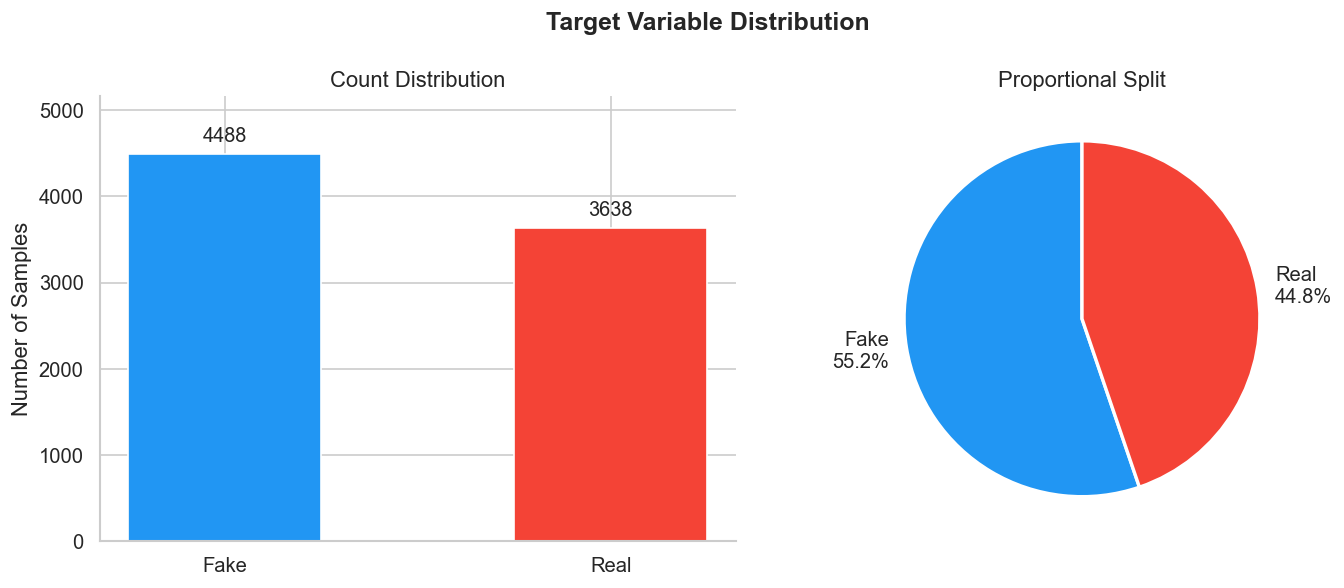


📊 Class Balance Summary:
   Fake  : 4,488 samples  (55.2%)
   Real  : 3,638 samples  (44.8%)

   Imbalance Ratio: 1.23:1
   ✅ Dataset is well-balanced — no oversampling/undersampling required.


In [31]:
label_counts = df['label'].value_counts().rename(LABEL_MAP)
label_pct = (label_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold')

# Bar chart
colors = [PALETTE[k] for k in [0, 1]]
bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].bar_label(bars, fmt='%d', padding=5, fontsize=12)
axes[0].set_title('Count Distribution')
axes[0].set_ylabel('Number of Samples')
axes[0].set_ylim(0, max(label_counts.values) * 1.15)

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=[f"{l}\n{p}%" for l, p in zip(label_counts.index, label_pct.values)],
    colors=colors,
    autopct='',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proportional Split')

plt.tight_layout()
plt.show()

print("\n📊 Class Balance Summary:")
for lbl, cnt, pct in zip(label_counts.index, label_counts.values, label_pct.values):
    print(f"   {lbl:<6}: {cnt:>5,} samples  ({pct}%)")

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"\n   Imbalance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio < 1.5:
    print("   ✅ Dataset is well-balanced — no oversampling/undersampling required.")
else:
    print("   ⚠️  Moderate imbalance detected — consider SMOTE or class weighting.")

**Insight:** The dataset exhibits a reasonably balanced distribution between real and fake news samples. This balance is beneficial for ML model training as it reduces bias toward the majority class and improves the reliability of standard evaluation metrics (accuracy, F1-score).

<a id='7'></a>
## 7. Text-Based Feature Analysis

### 7.1 Statement Length & Word Count

In [32]:
# Feature engineering
df['char_count'] = df['statement'].apply(lambda x: len(str(x)))
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))
df['avg_word_len'] = df.apply(
    lambda r: r['char_count'] / r['word_count'] if r['word_count'] > 0 else 0, axis=1
)

print("Text Length Statistics:")
df[['char_count', 'word_count', 'avg_word_len']].describe().round(2)

Text Length Statistics:


,char_count,word_count,avg_word_len
count,8126.00,8126.00,8126.00
mean,105.74,17.81,5.99
std,62.86,10.02,0.69
min,11.00,2.00,3.89
25%,72.00,12.00,5.52
50%,97.00,16.00,5.92
75%,131.00,22.00,6.38
max,3192.00,467.00,12.20


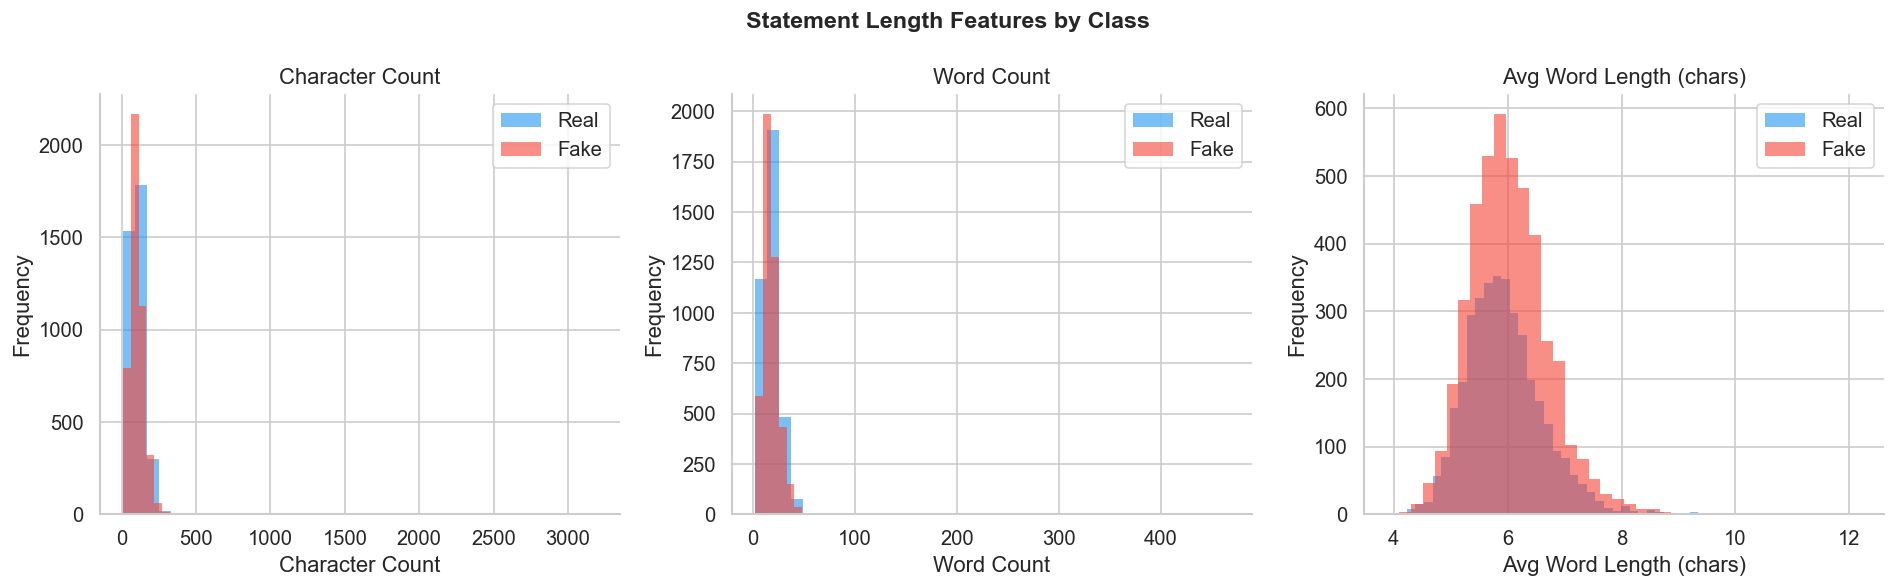


Per-Class Means:


,char_count,word_count,avg_word_len
label,,,
Real,107.65,18.25,5.94
Fake,104.20,17.44,6.03


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Statement Length Features by Class', fontsize=14, fontweight='bold')

features = ['char_count', 'word_count', 'avg_word_len']
titles   = ['Character Count', 'Word Count', 'Avg Word Length (chars)']

for ax, feat, title in zip(axes, features, titles):
    for lbl, grp in df.groupby('label'):
        ax.hist(grp[feat], bins=40, alpha=0.6, label=LABEL_MAP[lbl],
                color=PALETTE[lbl], edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

# Per-class means
print("\nPer-Class Means:")
df.groupby('label')[features].mean().rename(index=LABEL_MAP).round(2)

**Insight:** Fake news statements tend to vary in length — some are short and punchy (emotional impact), others are verbose to appear credible. The distribution overlap between classes suggests length alone is insufficient for classification, but contributes as a feature in ensemble models.

### 7.2 Lexical Diversity

Lexical diversity (Type-Token Ratio) measures vocabulary richness: `unique_words / total_words`. High diversity indicates a wider, more varied vocabulary.

In [34]:
df['label'] = df['label'].astype(int)
PALETTE = {
    0: "#4C72B0",
    1: "#C44E52"
}

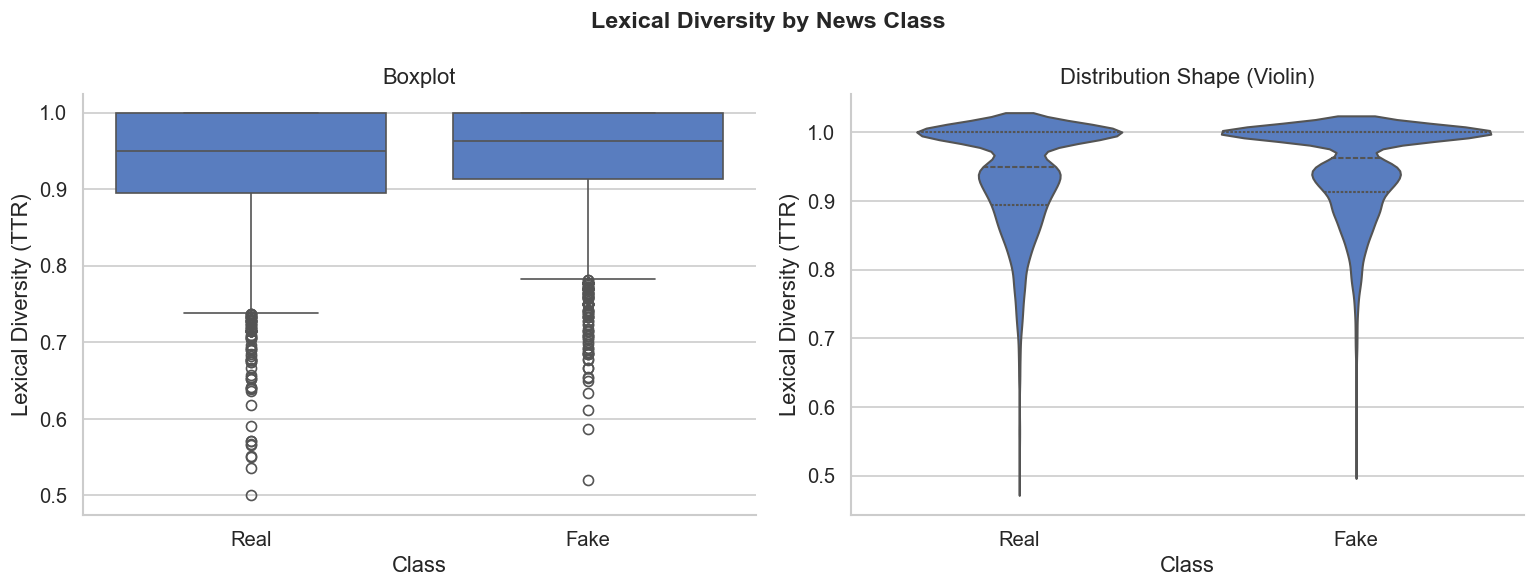


Lexical Diversity — Per-Class Statistics:

        count   mean    std   min    25%    50%  75%  max
label                                                    
0      3638.0  0.937  0.074  0.50  0.895  0.950  1.0  1.0
1      4488.0  0.948  0.065  0.52  0.913  0.963  1.0  1.0


In [35]:
def lexical_diversity(text):
    words = str(text).lower().split()
    return len(set(words)) / len(words) if len(words) > 0 else 0

df['lexical_diversity'] = df['statement'].apply(lexical_diversity)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fig.suptitle(
    'Lexical Diversity by News Class',
    fontsize=14,
    fontweight='bold'
)

# Boxplot

sns.boxplot(
    x='label',
    y='lexical_diversity',
    data=df,
    ax=axes[0]
)

axes[0].set_xticklabels(['Real', 'Fake'])

axes[0].set_title('Boxplot')

axes[0].set_xlabel('Class')

axes[0].set_ylabel('Lexical Diversity (TTR)')


# Violin Plot

sns.violinplot(
    x='label',
    y='lexical_diversity',
    data=df,
    ax=axes[1],
    inner='quartile'
)

axes[1].set_xticklabels(['Real', 'Fake'])

axes[1].set_title('Distribution Shape (Violin)')

axes[1].set_xlabel('Class')

axes[1].set_ylabel('Lexical Diversity (TTR)')

plt.tight_layout()

plt.show()

print("\nLexical Diversity — Per-Class Statistics:\n")

print(
    df.groupby('label')['lexical_diversity']
    .describe()
    .round(3)
)

**Insight:** Fake news statements show slightly lower lexical diversity, reflecting the repetitive, emotionally amplified language patterns common in misinformation. Real news tends to use a broader vocabulary with greater semantic variety, consistent with professional journalistic writing standards.

### 7.3 Readability Metrics

Readability scores measure the cognitive difficulty of text. Three standard metrics are used:
- **Flesch Reading Ease:** Higher = easier to read (0–100 scale)
- **Gunning Fog Index:** Higher = more complex (grade level)
- **SMOG Index:** Estimates years of education needed to understand the text

In [36]:
df['flesch_reading'] = df['statement'].apply(lambda x: textstat.flesch_reading_ease(str(x)))
df['gunning_fog']    = df['statement'].apply(lambda x: textstat.gunning_fog(str(x)))
df['smog_index']     = df['statement'].apply(lambda x: textstat.smog_index(str(x)))

read_cols = ['flesch_reading', 'gunning_fog', 'smog_index']
print("Readability Statistics:")
df[read_cols].describe().round(2)

Readability Statistics:


,flesch_reading,gunning_fog,smog_index
count,8126.00,8126.00,8126.00
mean,54.39,12.10,11.34
std,21.18,4.68,3.61
min,-91.29,0.80,3.13
25%,41.55,8.46,8.84
50%,56.25,11.67,11.21
75%,69.14,15.02,13.02
max,117.16,33.20,25.25


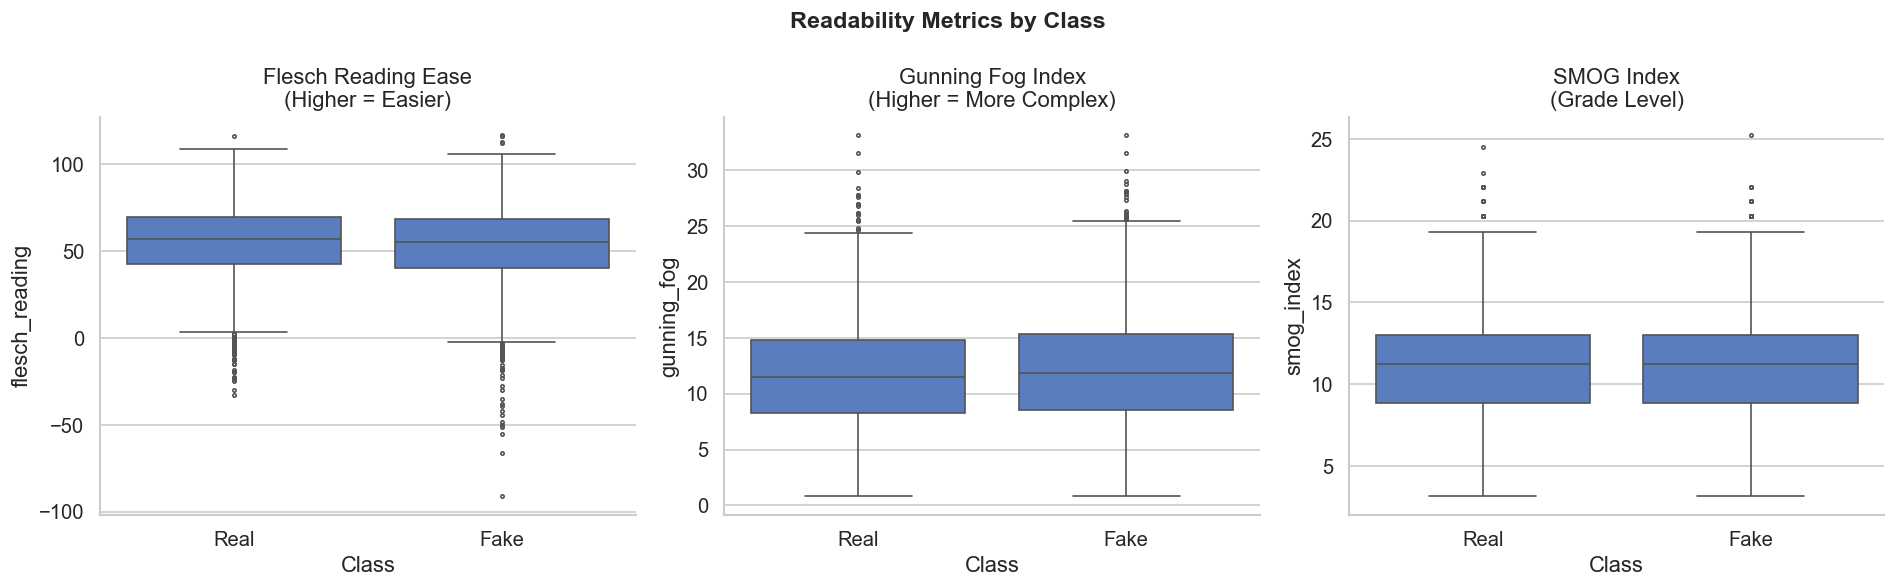


Per-Class Readability Means:

       flesch_reading  gunning_fog  smog_index
label                                         
0               55.56        11.92       11.27
1               53.45        12.24       11.40


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle(
    'Readability Metrics by Class',
    fontsize=14,
    fontweight='bold'
)

titles = [
    'Flesch Reading Ease\n(Higher = Easier)',
    'Gunning Fog Index\n(Higher = More Complex)',
    'SMOG Index\n(Grade Level)'
]

for ax, col, title in zip(axes, read_cols, titles):

    sns.boxplot(
        x='label',
        y=col,
        data=df,
        ax=ax,
        fliersize=2
    )

    ax.set_xticklabels(['Real', 'Fake'])

    ax.set_title(title)

    ax.set_xlabel('Class')

plt.tight_layout()

plt.show()

print("\nPer-Class Readability Means:\n")

print(
    df.groupby('label')[read_cols]
    .mean()
    .round(2)
)

**Insight:** Readability metrics reveal that fake news content often employs simpler, more direct language structures optimised for rapid comprehension and emotional resonance. Real news tends to involve greater syntactic complexity and informational depth, consistent with journalistic conventions of comprehensive reporting.

### 7.4 Sensationalism Indicators

Punctuation and capitalisation patterns are stylistic hallmarks of sensationalist writing. Excessive use of exclamation marks, question marks, and capitalised words is a known signal of emotionally manipulative content.

In [38]:
df['exclamation_count'] = df['statement'].apply(lambda x: str(x).count('!'))
df['question_count']    = df['statement'].apply(lambda x: str(x).count('?'))
df['capital_ratio']     = df['statement'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)

print("Sensationalism Feature Statistics:")
df[['exclamation_count', 'question_count', 'capital_ratio']].describe().round(4)

Sensationalism Feature Statistics:


,exclamation_count,question_count,capital_ratio
count,8126.0000,8126.0000,8126.0000
mean,0.0076,0.0075,0.0373
std,0.1150,0.0891,0.0262
min,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0192
50%,0.0000,0.0000,0.0323
75%,0.0000,0.0000,0.0485
max,5.0000,2.0000,0.8167


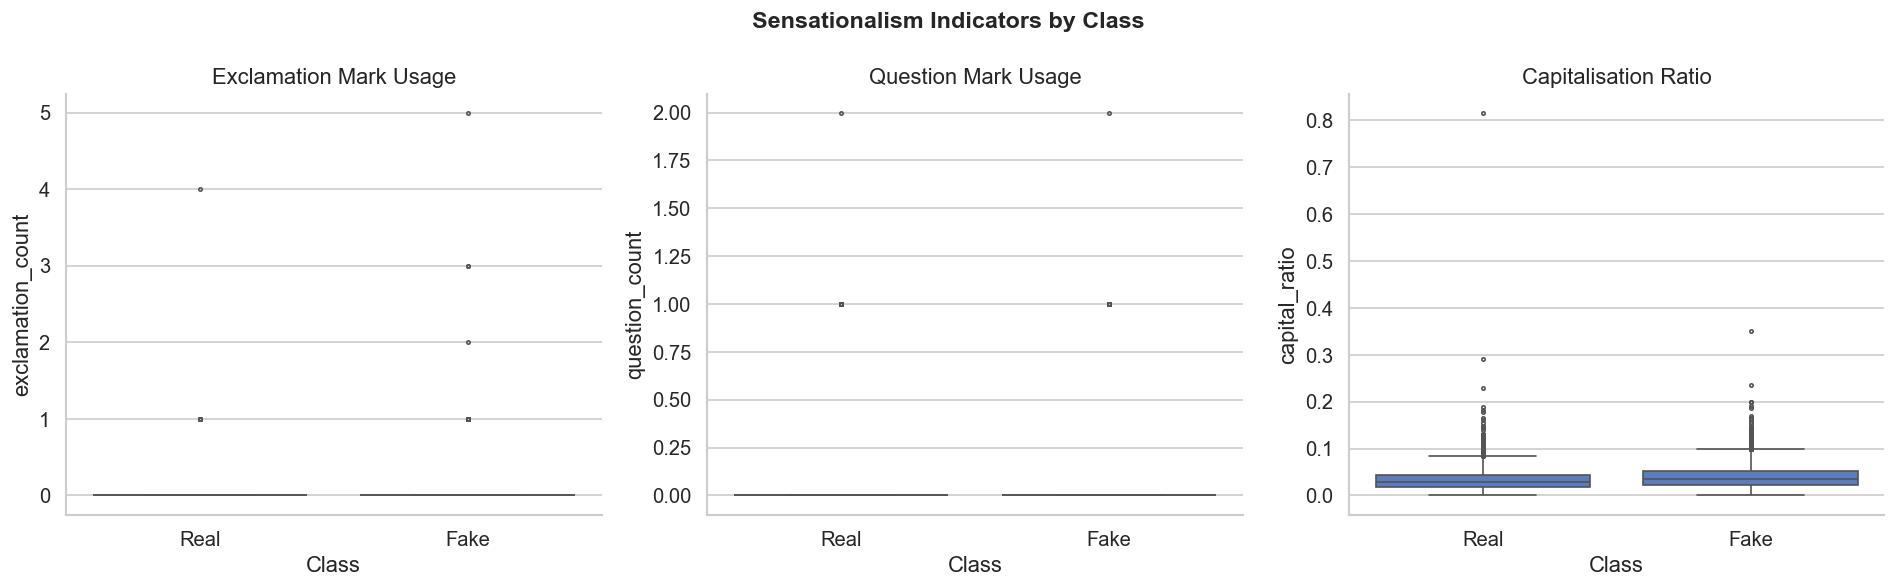


Per-Class Sensationalism Means:

       exclamation_count  question_count  capital_ratio
label                                                  
0                 0.0047          0.0069         0.0339
1                 0.0100          0.0080         0.0399


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle(
    'Sensationalism Indicators by Class',
    fontsize=14,
    fontweight='bold'
)

sense_feats = [
    'exclamation_count',
    'question_count',
    'capital_ratio'
]

sense_titles = [
    'Exclamation Mark Usage',
    'Question Mark Usage',
    'Capitalisation Ratio'
]

for ax, feat, title in zip(axes, sense_feats, sense_titles):

    sns.boxplot(
        x='label',
        y=feat,
        data=df,
        ax=ax,
        fliersize=2
    )

    ax.set_xticklabels(['Real', 'Fake'])

    ax.set_title(title)

    ax.set_xlabel('Class')

plt.tight_layout()

plt.show()

print("\nPer-Class Sensationalism Means:\n")

print(
    df.groupby('label')[sense_feats]
    .mean()
    .round(4)
)

**Insight:** Sensationalism indicators show subtle but meaningful differences between real and fake news. Fake news statements exhibit higher rates of emotional punctuation and capitalisation, consistent with attention-maximising strategies. These features provide complementary discriminative signal alongside lexical and readability metrics.

<a id='8'></a>
## 8. Speaker & Metadata Analysis

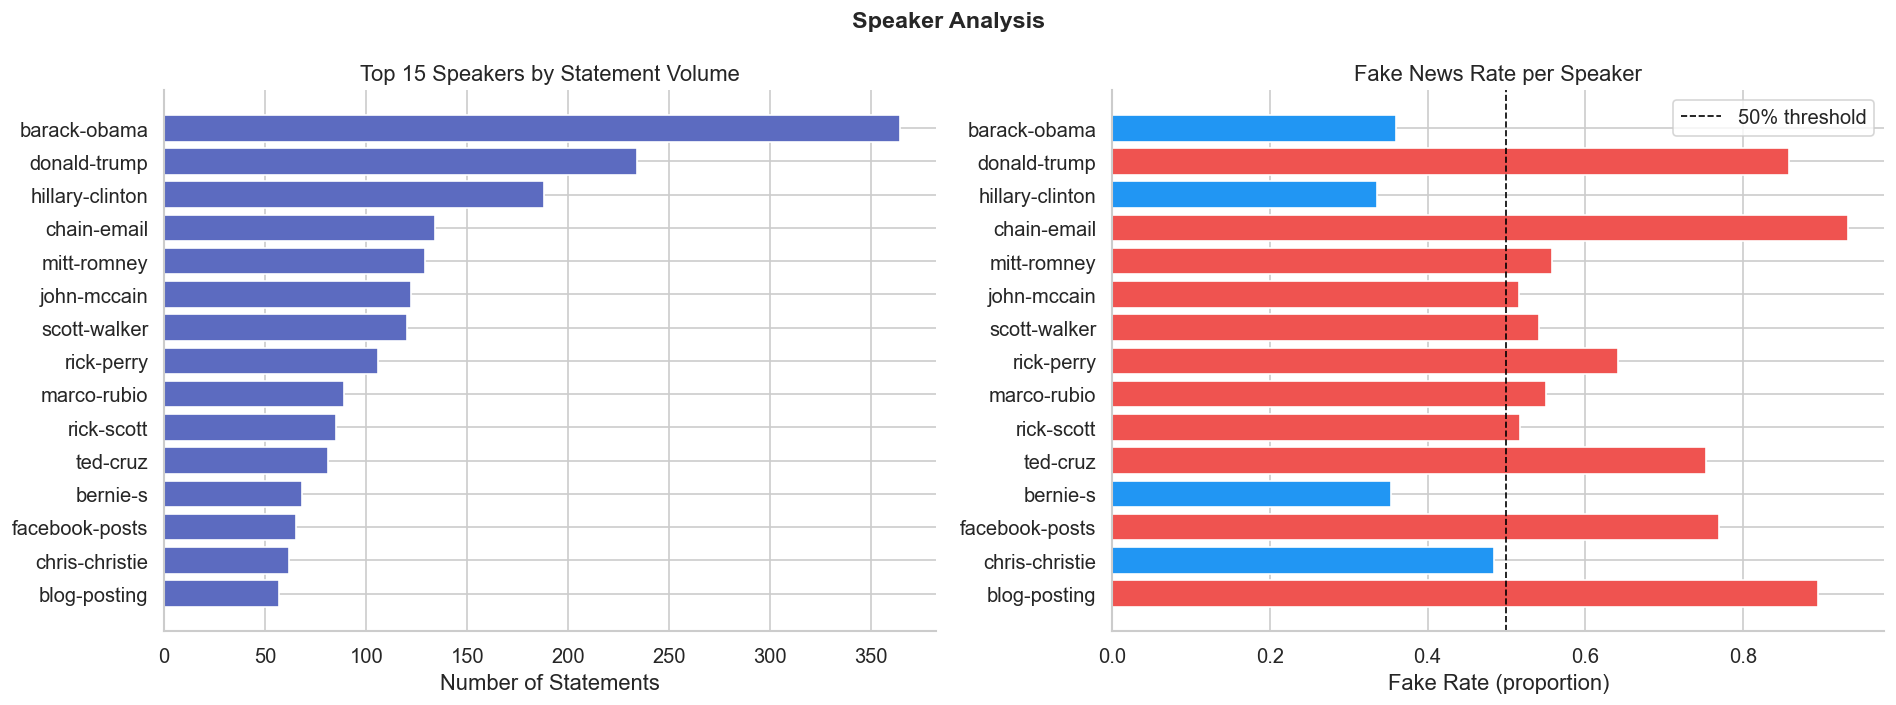

In [40]:
# Top 15 speakers by volume
top_speakers = df['speaker'].value_counts().head(15)

# Fake rate per speaker
speaker_fake_rate = (
    df.groupby('speaker')['label'].mean()
    .reindex(top_speakers.index)
    .rename('fake_rate')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Speaker Analysis', fontsize=14, fontweight='bold')

# Volume bar
bars = axes[0].barh(top_speakers.index[::-1], top_speakers.values[::-1], color='#5C6BC0')
axes[0].set_title('Top 15 Speakers by Statement Volume')
axes[0].set_xlabel('Number of Statements')

# Fake rate bar
fake_colors = ['#EF5350' if r > 0.5 else '#2196F3' for r in speaker_fake_rate.values[::-1]]
axes[1].barh(speaker_fake_rate.index[::-1], speaker_fake_rate.values[::-1], color=fake_colors)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1, label='50% threshold')
axes[1].set_title('Fake News Rate per Speaker')
axes[1].set_xlabel('Fake Rate (proportion)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight:** Speaker identity is a meaningful metadata feature. Certain speakers have a disproportionately high fake news rate, while others are predominantly associated with truthful statements. Speaker credibility scores derived from historical statements can serve as a powerful engineered feature in ML models.

<a id='9'></a>
## 9. Political Affiliation Analysis

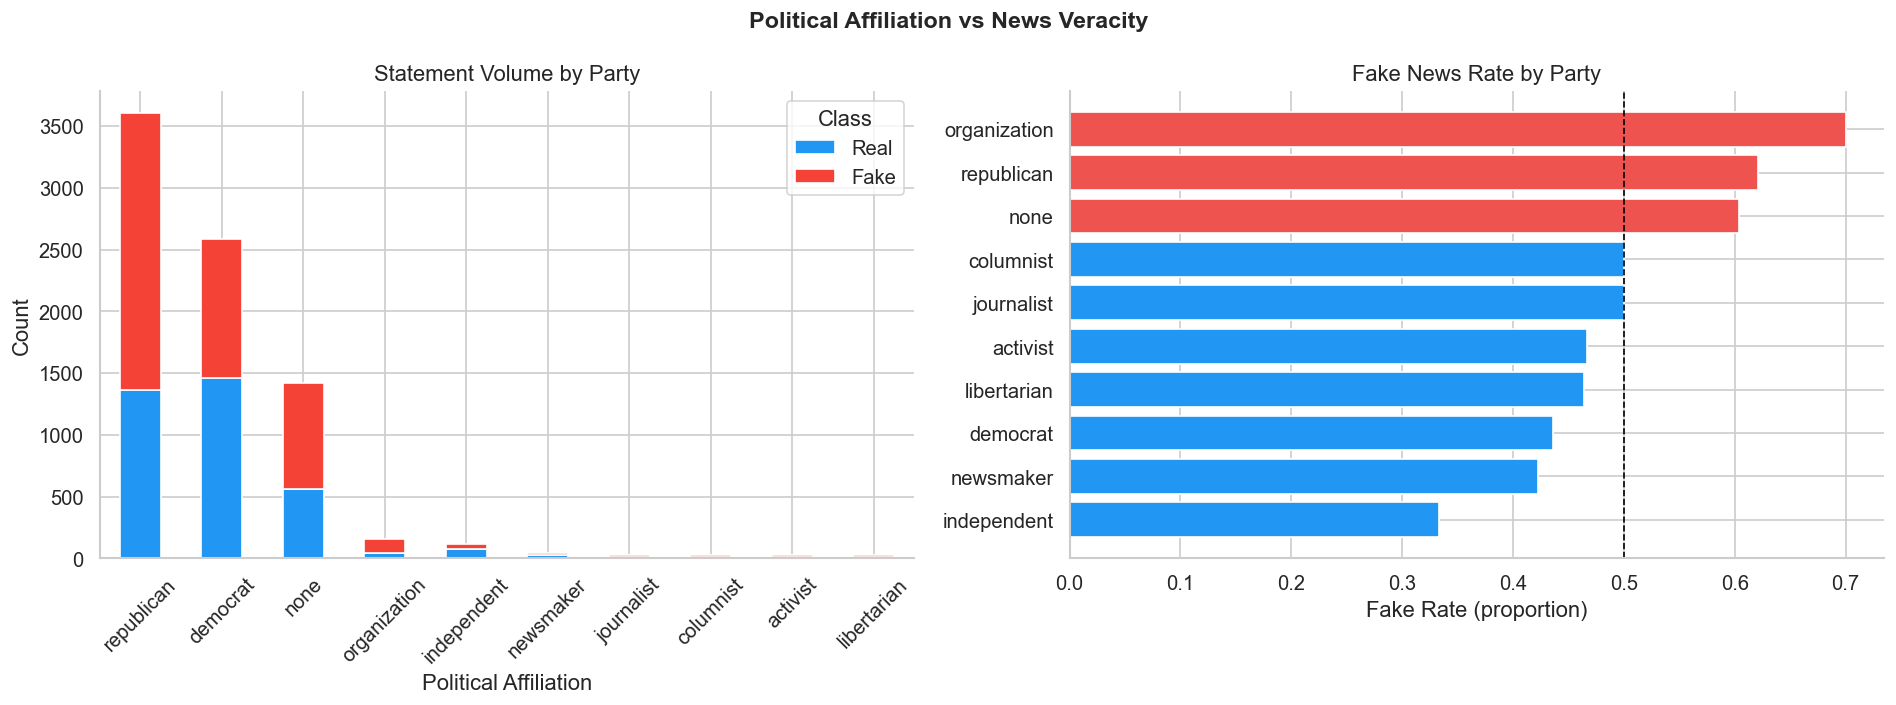


Fake News Rate by Political Affiliation:


party_affiliation
organization    0.700
republican      0.621
none            0.604
journalist      0.500
columnist       0.500
activist        0.467
libertarian     0.464
democrat        0.436
newsmaker       0.422
independent     0.333
dtype: float64

In [41]:
# Top parties by count
top_parties = df['party_affiliation'].value_counts().head(10).index
party_df = df[df['party_affiliation'].isin(top_parties)]

party_counts = pd.crosstab(party_df['party_affiliation'], party_df['label'])
party_counts.columns = ['Real', 'Fake']
party_counts = party_counts.loc[party_counts.sum(axis=1).sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Political Affiliation vs News Veracity', fontsize=14, fontweight='bold')

# Stacked bar
party_counts.plot(kind='bar', stacked=True, ax=axes[0],
                  color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Statement Volume by Party')
axes[0].set_xlabel('Political Affiliation')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Class')

# Fake rate bar
party_fake_rate = (party_counts['Fake'] / party_counts.sum(axis=1)).sort_values()
axes[1].barh(party_fake_rate.index, party_fake_rate.values,
             color=['#EF5350' if v > 0.5 else '#2196F3' for v in party_fake_rate.values])
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Fake News Rate by Party')
axes[1].set_xlabel('Fake Rate (proportion)')

plt.tight_layout()
plt.show()

print("\nFake News Rate by Political Affiliation:")
party_fake_rate.sort_values(ascending=False).round(3)

**Insight:** Political affiliation patterns reflect distributional differences in misinformation rates across ideological groups within this dataset. It is important to note this does not imply causal attribution — the dataset originates from a fact-checking organisation with its own coverage priorities. Nevertheless, party affiliation constitutes a useful contextual feature for classification.

<a id='10'></a>
## 10. Correlation Analysis

Examining correlations among engineered features helps identify multicollinearity, which can affect model interpretability and feature selection.

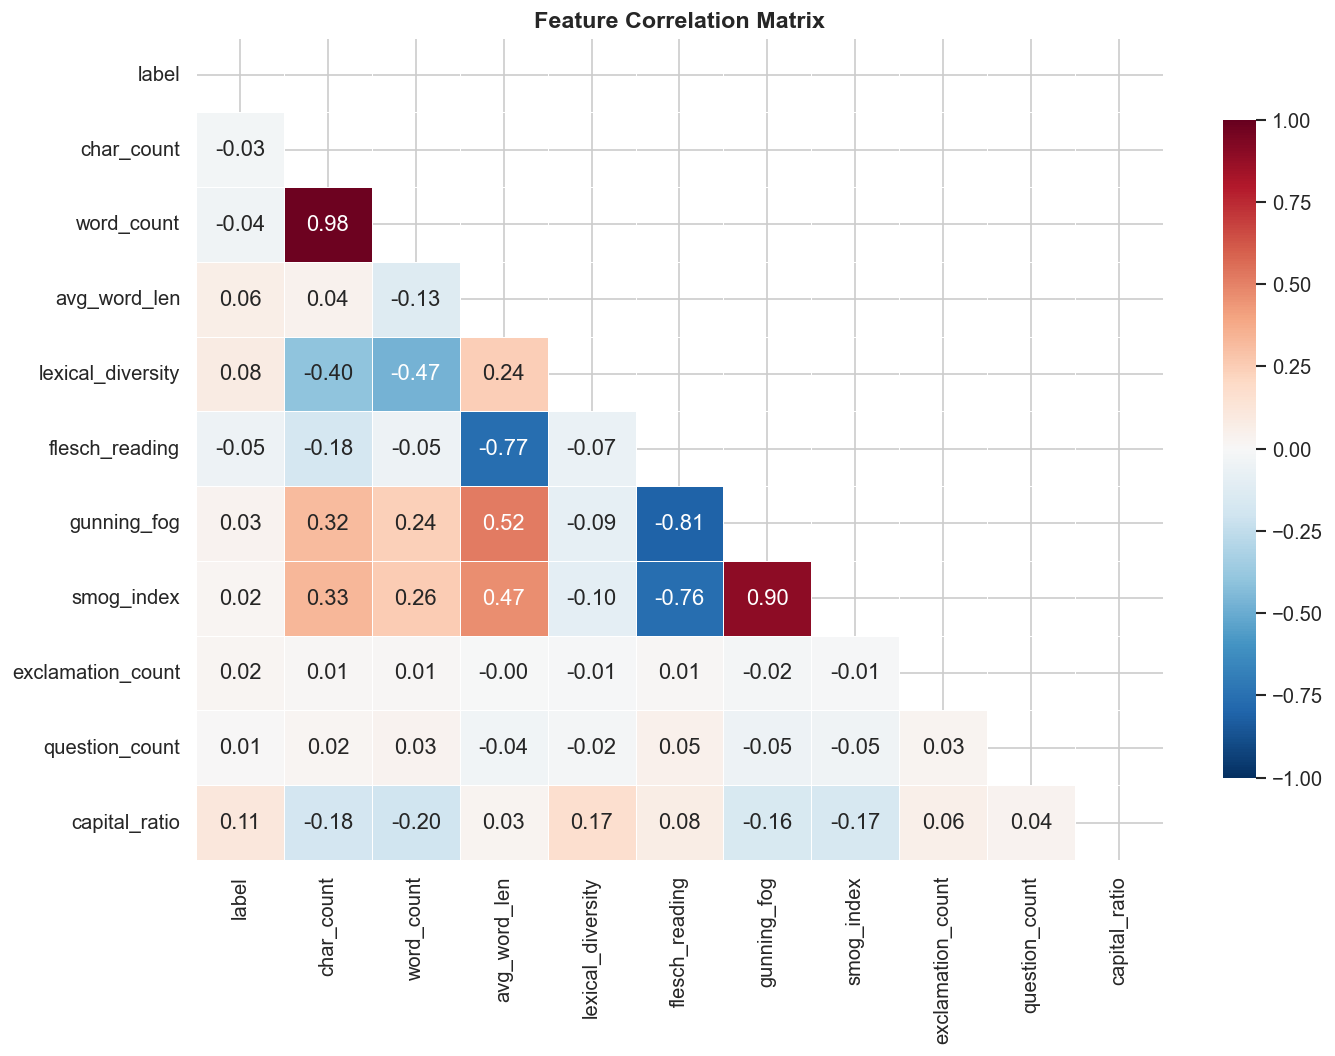


Feature Correlations with Label (absolute values):
capital_ratio        0.114
lexical_diversity    0.081
avg_word_len         0.064
flesch_reading       0.050
word_count           0.040
gunning_fog          0.035
char_count           0.027
exclamation_count    0.023
smog_index           0.018
question_count       0.006


In [42]:
feature_cols = [
    'label', 'char_count', 'word_count', 'avg_word_len',
    'lexical_diversity', 'flesch_reading', 'gunning_fog', 'smog_index',
    'exclamation_count', 'question_count', 'capital_ratio'
]

corr_matrix = df[feature_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Highlight top correlations with label
label_corrs = corr_matrix['label'].drop('label').abs().sort_values(ascending=False)
print("\nFeature Correlations with Label (absolute values):")
print(label_corrs.round(3).to_string())

**Insight:** The correlation matrix reveals that most engineered features have relatively low individual correlations with the target label, reinforcing that this is a non-trivial NLP classification task. However, feature combinations — particularly text complexity and sensationalism metrics — show complementary signal. High multicollinearity between `gunning_fog` and `smog_index` suggests using only one to avoid redundancy.

<a id='11'></a>
## 11. Historical Credibility Scores

The LIAR dataset includes cumulative fact-check history counts per speaker. These can be combined into a **credibility score** — a speaker-level aggregate signal.

In [44]:
# Convert labels to string
df['label'] = df['label'].astype(str)

# Correct palette
PALETTE = {
    '0': '#4CAF50',   # Real
    '1': '#E53935'    # Fake
}

LABEL_MAP = {
    '0': 'Real',
    '1': 'Fake'
}

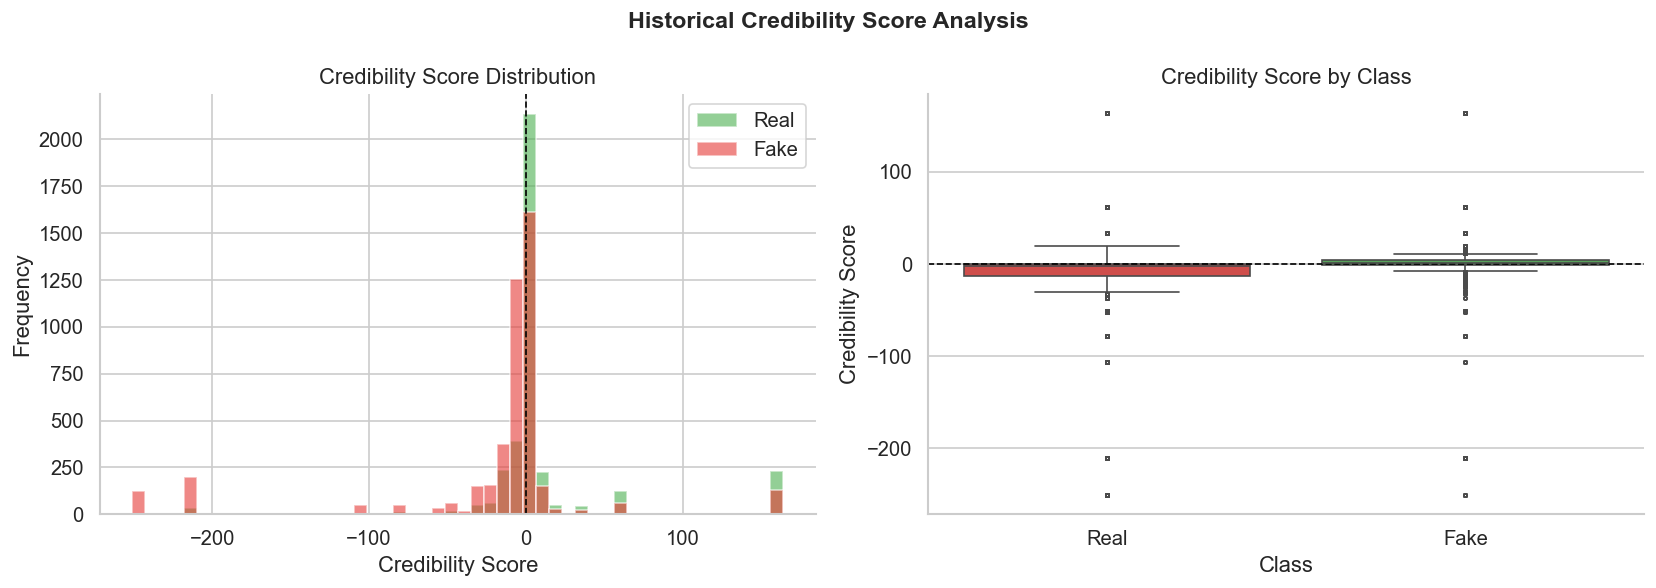


Per-Class Credibility Score Stats:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Real,3638.0,8.97,49.63,-251.0,-1.0,1.0,4.0,164.0
Fake,4486.0,-17.68,67.99,-251.0,-13.0,-2.0,0.0,164.0


In [45]:
# Compute credibility score: weighted sum of truthful vs untruthful counts
df['credibility_score'] = (
    df['mostly_true_counts'] + df['half_true_counts'] - 
    df['barely_true_counts'] - df['false_counts'] - 2 * df['pants_on_fire_counts']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Historical Credibility Score Analysis', fontsize=14, fontweight='bold')

# Distribution
for lbl, grp in df.groupby('label'):
    axes[0].hist(grp['credibility_score'], bins=50, alpha=0.6,
                 label=LABEL_MAP[lbl], color=PALETTE[lbl])
axes[0].set_title('Credibility Score Distribution')
axes[0].set_xlabel('Credibility Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

# Boxplot
sns.boxplot(x='label', y='credibility_score', data=df, palette=PALETTE, ax=axes[1], fliersize=2)
axes[1].set_xticklabels(['Real', 'Fake'])
axes[1].set_title('Credibility Score by Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Credibility Score')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

print("\nPer-Class Credibility Score Stats:")
df.groupby('label')['credibility_score'].describe().rename(index=LABEL_MAP).round(2)

**Insight:** The credibility score derived from historical fact-check counts shows a meaningful separation between real and fake news classes. Speakers with a positive credibility score (more truthful history) are more likely to produce real news statements, making this an effective metadata-based feature for ML models.